# WEEK 3: DATA PREPROCESSING AND REGRESSION

### Chirag Rao K V
### Roll No: 16
### Reg No: 240962180

In [260]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

Consider the hepatitis/ pima-indians-diabetes csv file, perform the following date pre-processing.
1. Load data in Pandas.
2. Drop columns that aren’t useful.
3. Drop rows with missing values.
4. Create dummy variables.
5. Take care of missing data.
6. Convert the data frame to NumPy.
7. Divide the data set into training data and test data.

In [261]:
data = pd.read_csv('hepatitis_csv.csv')
data.columns


Index(['age', 'sex', 'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia',
       'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 'ascites',
       'varices', 'bilirubin', 'alk_phosphate', 'sgot', 'albumin', 'protime',
       'histology', 'class'],
      dtype='str')

In [262]:
# dropping columns that are not useful
# All columns are relevant
data.drop_duplicates(inplace=True)
print(data['class'].value_counts(dropna=False))
print(data['class'].unique())

class
live    123
die      32
Name: count, dtype: int64
<StringArray>
['live', 'die']
Length: 2, dtype: str


In [263]:
data['sex'] = data['sex'].map({'male': 0, 'female': 1})
data['class'] = data['class'].map({'live': 1, 'die': 0})
columns_to_convert = [
    'steroid', 'antivirals', 'fatigue', 'malaise', 'anorexia', 
    'liver_big', 'liver_firm', 'spleen_palpable', 'spiders', 
    'ascites', 'varices', 'histology' ]
for col in columns_to_convert:
    if col in data.columns:
        data[col] = data[col].map({True: 1, False: 0, 'True': 1, 'False': 0}).astype('Int64')

data


,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,spiders,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class
0,30,0,0,0,0,0,0,0,0,0,0,0,0,1.0,85.0,18.0,4.0,NaN,0,1
1,50,1,0,0,1,0,0,0,0,0,0,0,0,0.9,135.0,42.0,3.5,NaN,0,1
2,78,1,1,0,1,0,0,1,0,0,0,0,0,0.7,96.0,32.0,4.0,NaN,0,1
3,31,1,<NA>,1,0,0,0,1,0,0,0,0,0,0.7,46.0,52.0,4.0,80.0,0,1
4,34,1,1,0,0,0,0,1,0,0,0,0,0,1.0,NaN,200.0,4.0,NaN,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,46,1,1,0,1,1,1,1,0,0,1,1,1,7.6,NaN,242.0,3.3,50.0,1,0
151,44,1,1,0,1,0,0,1,1,0,0,0,0,0.9,126.0,142.0,4.3,NaN,1,1
152,61,1,0,0,1,1,0,0,1,0,1,0,0,0.8,75.0,20.0,4.1,NaN,1,1
153,53,0,0,0,1,0,0,1,0,1,1,0,1,1.5,81.0,19.0,4.1,48.0,1,1


In [264]:
#create dummy variables
data['sgot+albumin'] = data['sgot'] + data['albumin']
data = data.fillna(data.median(numeric_only=True))

In [265]:
#converting data frame to numpy
data_numpy = data.to_numpy()
data_numpy

array([[30, 0, 0, ..., 0, 1, 22.0],
       [50, 1, 0, ..., 0, 1, 45.5],
       [78, 1, 1, ..., 0, 1, 36.0],
       ...,
       [61, 1, 0, ..., 1, 1, 24.1],
       [53, 0, 0, ..., 1, 1, 23.1],
       [43, 1, 1, ..., 1, 0, 22.1]], shape=(155, 21), dtype=object)

In [266]:
data_shuffled = data.sample(frac=1, random_state=42).reset_index(drop=True)
train_size = int(len(data_shuffled) * 0.8)
train_data = data_shuffled.iloc[:train_size]
test_data = data_shuffled.iloc[train_size:]

2. a. Construct a CSV file with the following attributes:

1. Study time in hours of ML lab course (x)
2. Score out of 10 (y)
3. The dataset should contain 10 rows.

In [267]:

df = {
    "time": [1, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6, 7],
    "Score": [2.1, 3.8, 4.6, 5.2, 5.9, 6.3, 7.1, 7.4, 8.3, 9.2]
}
df = pd.DataFrame(df)
df

,time,Score
0,1.0,2.1
1,2.0,3.8
2,2.5,4.6
3,3.0,5.2
4,3.5,5.9
5,4.0,6.3
6,4.5,7.1
7,5.0,7.4
8,6.0,8.3
9,7.0,9.2


2.b Create a regression model and display the following:
1. Coefficients: B0 (intercept) and B1 (slope)
2. RMSE (Root Mean Square Error)
3. Predicted responses

/tmp/ipykernel_5035/122773692.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


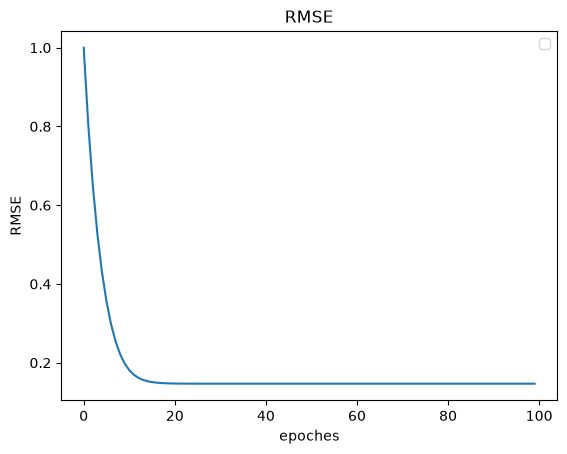

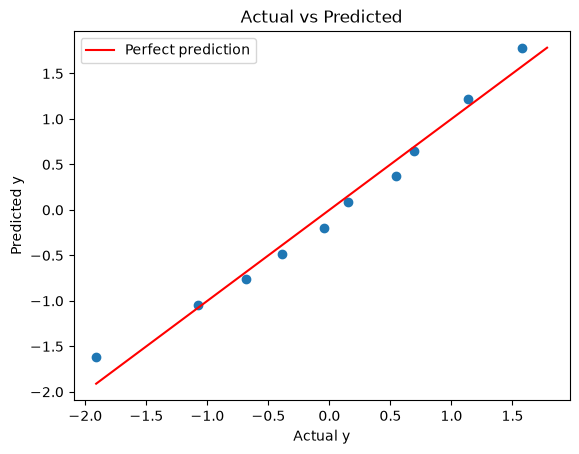

In [282]:
class Linear_Regression:
    def __init__(self, x, y):
        self.x = np.asarray(x)
        self.y = np.asarray(y)

        if self.x.ndim == 1:
            self.x = self.x.reshape(-1, 1)

        self.weights = np.zeros(self.x.shape[1])
        self.bias = 0

    def loss(self,pred,actual):
        self.loss_ = np.sqrt(np.mean((actual-pred)**2))
        return self.loss_

    def predict(self,x):
        return x @ self.weights + self.bias

    def train(self,no_epoch,alpha,norm_y=True):
        self.x = (self.x-np.mean(self.x,axis=0))/np.std(self.x,axis=0)
        if(norm_y):
            self.y = (self.y-np.mean(self.y))/np.std(self.y)
        self.loss_train = []

        for i in range(no_epoch):
            y_pred = self.x @ self.weights + self.bias
            dw = (-2 / len(self.x)) * (self.x.T @ (self.y - y_pred))
            db = (-2 / len(self.x)) * np.sum(self.y - y_pred)

            self.weights = self.weights - alpha * dw
            self.bias = self.bias - alpha * db
            self.loss_train.append(self.loss(y_pred,self.y))

        plt.plot(range(len(self.loss_train)), self.loss_train)

        plt.legend()
        plt.xlabel("epoches")
        plt.ylabel("RMSE")
        plt.show()

    def plot_data(self):
        y_pred = self.x @ self.weights + self.bias

        plt.scatter(self.y, y_pred)
        plt.xlabel("Actual y")
        plt.ylabel("Predicted y")
        plt.title("Actual vs Predicted")
        
        # Perfect prediction line
        min_val = min(self.y.min(), y_pred.min())
        max_val = max(self.y.max(), y_pred.max())
        plt.plot([min_val, max_val],
                [min_val, max_val],
                color="red",
                label="Perfect prediction")

        plt.legend()
        plt.show()
LR = Linear_Regression(df['time'].to_numpy(),df['Score'].to_numpy())
plt.title("RMSE")
LR.train(100,0.1)
LR.plot_data()

c. Create a scatter plot of the data points in red color and plot the graph of x vs. predicted y in blue color.

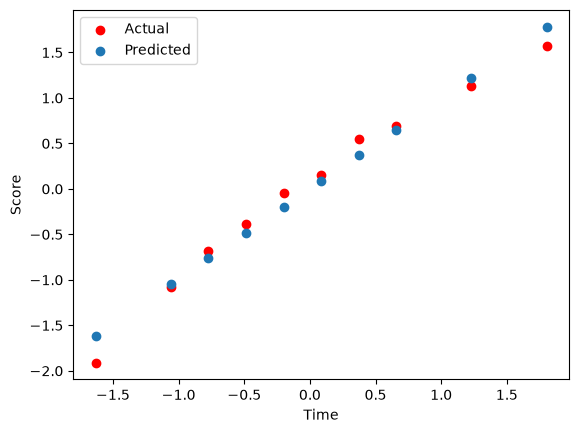

In [283]:
plt.scatter(LR.x,LR.y,color='red',label="Actual")
plt.scatter(LR.x,LR.predict(LR.x),label="Predicted")
plt.xlabel("Time")
plt.ylabel("Score")
plt.legend()
plt.show()


Slope: 1.1526617526617529
Intercept: 1.5522522522522513


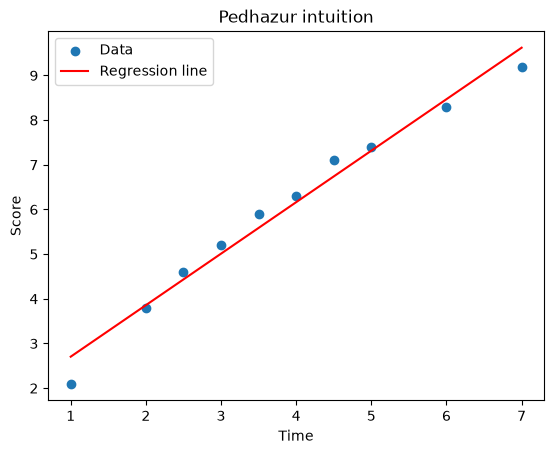

In [284]:
x = np.array(df["time"])
y = np.array(df["Score"])
x_mean = np.mean(x)
y_mean = np.mean(y)
b1 = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean) ** 2)
b0 = y_mean - b1 * x_mean
y_pred = b0 + b1 * x
print("Slope:", b1)
print("Intercept:", b0)
plt.scatter(x, y, label="Data")
plt.plot(x, y_pred, color="red", label="Regression line")
plt.xlabel("Time")
plt.ylabel("Score")
plt.title("Pedhazur intuition")
plt.legend()
plt.show()

Compare the coefficients obtained using both methods and compare them with the analytical solution.

In [285]:
print(f"{'':12} | {'Calculus':12} | {'Pedhazur':12}")
print("-" * 42)
print(f"{'Slope':12} | {LR.weights[0]:12.4f} | {b1:12.4f}")
print(f"{'Intercept':12} | {LR.bias:12.4f} | {b0:12.4f}")

             | Calculus     | Pedhazur    
------------------------------------------
Slope        |       0.9892 |       1.1527
Intercept    |      -0.0000 |       1.5523


f. Test your model to predict the score obtained when the study time of a student is 10 hou

In [286]:
print(f"Pridicted score for 10 hours of study",LR.predict(np.array([10])))

Pridicted score for 10 hours of study 9.89173994899337


In [287]:
data

,age,sex,steroid,antivirals,fatigue,malaise,anorexia,liver_big,liver_firm,spleen_palpable,...,ascites,varices,bilirubin,alk_phosphate,sgot,albumin,protime,histology,class,sgot+albumin
0,30,0,0,0,0,0,0,0,0,0,...,0,0,1.0,85.0,18.0,4.0,61.0,0,1,22.0
1,50,1,0,0,1,0,0,0,0,0,...,0,0,0.9,135.0,42.0,3.5,61.0,0,1,45.5
2,78,1,1,0,1,0,0,1,0,0,...,0,0,0.7,96.0,32.0,4.0,61.0,0,1,36.0
3,31,1,1,1,0,0,0,1,0,0,...,0,0,0.7,46.0,52.0,4.0,80.0,0,1,56.0
4,34,1,1,0,0,0,0,1,0,0,...,0,0,1.0,85.0,200.0,4.0,61.0,0,1,204.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150,46,1,1,0,1,1,1,1,0,0,...,1,1,7.6,85.0,242.0,3.3,50.0,1,0,245.3
151,44,1,1,0,1,0,0,1,1,0,...,0,0,0.9,126.0,142.0,4.3,61.0,1,1,146.3
152,61,1,0,0,1,1,0,0,1,0,...,0,0,0.8,75.0,20.0,4.1,61.0,1,1,24.1
153,53,0,0,0,1,0,0,1,0,1,...,0,1,1.5,81.0,19.0,4.1,48.0,1,1,23.1


# Additional Questions

c. Implement the model using two methods:
1. Pedhazur formula (intuitive)
2. Calculus method (partial derivatives, refer to class notes)

/tmp/ipykernel_5035/122773692.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


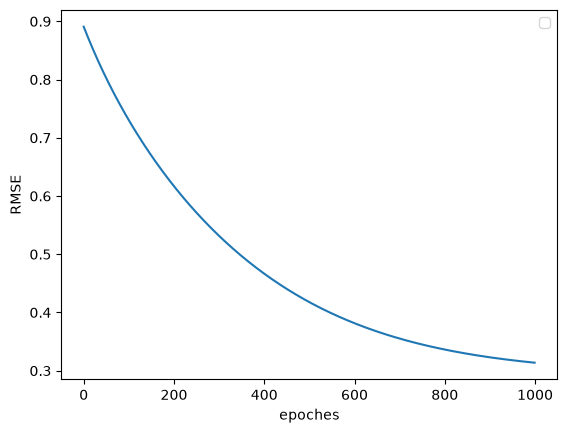

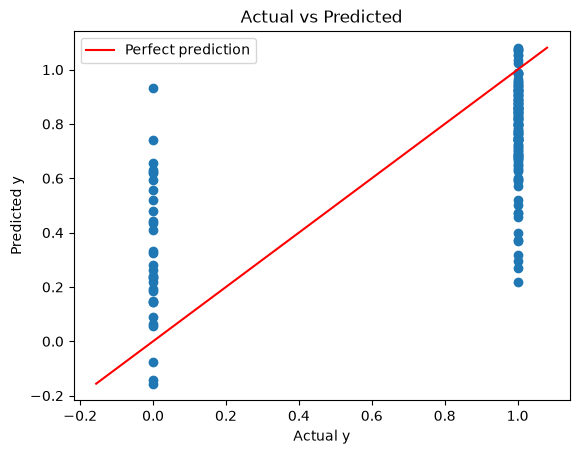

In [288]:
X = data.drop(columns=['class']).copy()
y = data['class'].to_numpy(dtype=float)
X = X.apply(pd.to_numeric, errors='coerce')
X = X.fillna(X.median())
X = X.to_numpy(dtype=float)
LR_c = Linear_Regression(X,y)
LR_c.train(1000,0.001,False)

LR_c.plot_data()

In [289]:
x = X.astype(float)
y = y.astype(float)
x_mean = np.mean(x, axis=0)
x_std = np.std(x, axis=0)
x_std[x_std == 0] = 1
X_scaled = (x - x_mean) / x_std
X_design = np.column_stack([
    np.ones(X_scaled.shape[0]),
    X_scaled
])
beta = np.linalg.inv(X_design.T @ X_design) @ X_design.T @ y
b0 = beta[0]
b1 = beta[1:]
y_pred = X_design @ beta
print("Intercept:", b0)
print("Slopes:", b1)


Intercept: 0.793548387096774
Slopes: [-0.03076399 -0.05691185  0.03397582 -0.01294845 -0.00105272 -0.07404546
  0.06143767 -0.03087382  0.03576127 -0.04003311 -0.08287291 -0.06764894
 -0.02921077 -0.08794003  0.01641331  0.01471057  0.04840513  0.02178694
 -0.01444195 -0.01078402]


d. Compare the coefficients obtained using both methods. For a given data point, check the predicted y
value

In [290]:
print(f"{'':12} | {'Calculus':12} | {'Pedhazur':12}")
print("-" * 42)
print(f"{'Slope':12} | {LR_c.weights[0]:12.4f} | {b1[0]:12.4f}")
print(f"{'Intercept':12} | {LR_c.bias:12.4f} | {b0:12.4f}")

             | Calculus     | Pedhazur    
------------------------------------------
Slope        |      -0.0334 |      -0.0308
Intercept    |       0.6864 |       0.7935
